# MLP em PyTorch com Loop de Treinamento, Early Stopping e Batching

## Objetivo
Implementar um **loop de treinamento explícito** com **validação**, **early stopping** (paciência sobre loss de validação) e **batching** organizado via `DataLoader`. Este notebook estende o trabalho do notebook `03_mlp_pytorch.ipynb` com **práticas realistas e reprodutíveis** de engenharia de ML.

### Por que esta etapa?
No notebook anterior (`03_mlp_pytorch.ipynb`) treinamos um MLP de forma simples. Aqui, refinamos essa abordagem com:
- **Split treino/validação/teste:** Mais rigoroso na avaliação de generalização.
- **Loop explícito:** Controle fino sobre cada epoch e possibilidade de logging.
- **Early stopping:** Para o treinamento quando a validação não melhora, economizando tempo e evitando overfitting.
- **Batching organizado:** Uso consciente de `DataLoader` com shuffle no treino.
- **MLflow:** Rastreabilidade de parâmetros, métricas e modelo final.

## O que será feito (passo a passo) e por quê

1. Carregar dados do EDA (`Telco_customer_churn_ready.csv`) — dados já limpos e codificados.
2. Dividir em **treino (64%), validação (16%) e teste (20%)** com estratificação — manter proporção de churn em cada split.
3. Padronizar features com `StandardScaler` **apenas ajustado no treino** — evitar vazamento de informação.
4. Criar `DataLoader` com batching — eficiência computacional e regularização.
5. Definir MLP com `torch.nn.Module` — arquitetura repeatable com ReLU e BCEWithLogitsLoss.
6. Implementar loop de treinamento e validação — iteração época por época com feedback.
7. Adicionar **early stopping** com paciência sobre loss de validação — parar no tempo certo.
8. Avaliar no **conjunto de teste** com ≥4 métricas — acurácia, precisão, recall, F1, ROC-AUC.
9. Registrar tudo no **MLflow** — rastreabilidade de parâmetros, métricas e modelo.
10. Gerar visualizações (loss curves, matriz de confusão) — interpretabilidade do treinamento.

In [1]:
from pathlib import Path
from copy import deepcopy
import hashlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.pytorch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
)

# Seed para reprodutibilidade.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Define dispositivo (GPU se disponível, senão CPU).
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

# Caminho de entrada (mesmo arquivo gerado no EDA).
DATA_PATH = Path("../data/Telco_customer_churn_ready.csv")
TARGET = "Churn Value"

assert DATA_PATH.exists(), (
    f"Arquivo não encontrado em {DATA_PATH.resolve()}\n"
    "Execute o notebook de EDA para gerar o CSV tratado."
)

print(f"Arquivo de entrada encontrado: {DATA_PATH.resolve()}")

Dispositivo: cpu
Arquivo de entrada encontrado: C:\Users\azvef\Projeto FIAP 1\9mlet-tech-challenge-1-churn-prevision\data\Telco_customer_churn_ready.csv


## Carregamento e Exploração dos Dados

In [2]:
# Carrega o dataset já tratado no EDA.
TARGET = "Churn Value"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nPrimeiras colunas: {df.columns.tolist()[:10]}")

# Verifica a coluna alvo.
assert TARGET in df.columns, f"Coluna alvo '{TARGET}' não encontrada."
print(f"\nDistribuição do alvo (proporção):\n{df[TARGET].value_counts(normalize=True)}")

display(df.head(3))

Shape: (7043, 1163)

Primeiras colunas: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'City_Acton', 'City_Adelanto', 'City_Adin']

Distribuição do alvo (proporção):
Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64


,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,CLTV,City_Acton,City_Adelanto,City_Adin,...,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Churn Value
0,90003,33.964131,-118.272783,2,53.85,108.15,3239,False,False,False,...,False,False,False,False,False,True,False,False,True,1
1,90005,34.059281,-118.307420,2,70.70,151.65,2701,False,False,False,...,False,False,False,False,False,True,False,True,False,1
2,90006,34.048013,-118.293953,8,99.65,820.50,5372,False,False,False,...,True,False,True,False,False,True,False,True,False,1


In [3]:
# Separa features (X) e alvo (y).
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

# Converte para numpy com float32 (compatível com PyTorch e StandardScaler).
X_np = X.astype(np.float32).to_numpy()
y_np = y.to_numpy(dtype=np.float32)

# Split 1: Treino+Validação (80%) vs Teste (20%) — com estratificação.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_np,
    y_np,
    test_size=0.2,
    random_state=SEED,
    stratify=y_np,
)

# Split 2: Treino (75% de 80% = 60%) vs Validação (25% de 80% = 20%).
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=SEED,
    stratify=y_temp,
)

n_features = X_train.shape[1]
print(f"Treino: {len(X_train)} | Validação: {len(X_val)} | Teste: {len(X_test)}")
print(f"Total de features: {n_features}")

Treino: 4225 | Validação: 1409 | Teste: 1409
Total de features: 1162


In [4]:
# Padroniza features com StandardScaler — FIT APENAS NO TREINO (evita vazamento).
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_val_s = scaler.transform(X_val).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)

print("Padronização concluída (sem vazamento de validação/teste para treino).")
print(f"Média (treino) — primeiras 3 features: {X_train_s.mean(axis=0)[:3]}")
print(f"Desvio (treino) — primeiras 3 features: {X_train_s.std(axis=0)[:3]}")

Padronização concluída (sem vazamento de validação/teste para treino).
Média (treino) — primeiras 3 features: [-3.4196841e-08 -4.1476369e-09 -1.0425523e-08]
Desvio (treino) — primeiras 3 features: [0.99999976 1.         0.9999999 ]


## Criação de DataLoaders com Batching

In [5]:
# Hiperparâmetros de treinamento.
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS_MAX = 50  # Máximo; early stopping pode parar antes.
PATIENCE = 10  # Quantos epochs sem melhoria antes de parar.
THRESHOLD_PREDICTION = 0.5  # Threshold para converter prob → classe.

# Cria TensorDataset para cada split.
train_ds = TensorDataset(
    torch.from_numpy(X_train_s),
    torch.from_numpy(y_train).unsqueeze(1),  # Shape: (n, 1)
)
val_ds = TensorDataset(
    torch.from_numpy(X_val_s),
    torch.from_numpy(y_val).unsqueeze(1),
)
test_ds = TensorDataset(
    torch.from_numpy(X_test_s),
    torch.from_numpy(y_test).unsqueeze(1),
)

# Cria DataLoaders.
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 67 | Val batches: 23 | Test batches: 23


## Definição da Arquitetura MLP

In [6]:
class MLPChurn(nn.Module):
    """
    Perceptron multicamadas para classificação binária de churn.
    
    Arquitetura:
    - Entrada: input_dim features
    - Camada oculta 1: 64 neurônios + ReLU
    - Camada oculta 2: 32 neurônios + ReLU
    - Saída: 1 neurônio (logit, sem ativação)
    """

    def __init__(self, input_dim: int, hidden_dim_1: int = 64, hidden_dim_2: int = 32):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim_1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_dim_2, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x


# Instancia o modelo.
model = MLPChurn(input_dim=n_features).to(DEVICE)
print(f"Modelo instanciado no dispositivo: {DEVICE}")
print(model)

Modelo instanciado no dispositivo: cpu
MLPChurn(
  (fc1): Linear(in_features=1162, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


## Definição de Loss e Otimizador

In [7]:
# BCEWithLogitsLoss: combina sigmoid + binary cross-entropy de forma numericamente estável.
# Como churn é minoritário, usamos pos_weight para penalizar mais erros na classe positiva.
neg_count = float((y_train == 0).sum())
pos_count = float((y_train == 1).sum())
pos_weight_value = neg_count / max(pos_count, 1.0)
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

# Otimizador Adam: taxa adaptativa e funciona bem em muitos casos.
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: {criterion.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__} (lr={LEARNING_RATE})")
print(f"pos_weight aplicado na loss: {pos_weight_value:.4f} (neg/pos no treino)")

Loss function: BCEWithLogitsLoss
Optimizer: Adam (lr=0.001)
pos_weight aplicado na loss: 2.7690 (neg/pos no treino)


## Funções de Treinamento e Avaliação

In [8]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Treina o modelo por um epoch completo.
    
    Args:
        model: instância do modelo.
        dataloader: DataLoader com dados de treino.
        criterion: função de loss.
        optimizer: otimizador.
        device: 'cuda' ou 'cpu'.
    
    Returns:
        avg_loss: loss médio do epoch.
    """
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass.
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        # Backward pass.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(dataloader.dataset)
    return avg_loss


def evaluate(model, dataloader, criterion, device):
    """
    Avalia o modelo em um conjunto de dados.
    
    Args:
        model: instância do modelo.
        dataloader: DataLoader com dados para avaliar.
        criterion: função de loss.
        device: 'cuda' ou 'cpu'.
    
    Returns:
        avg_loss: loss médio.
        y_true: labels verdadeiros (numpy).
        y_proba: probabilidades preditas (numpy).
    """
    model.eval()
    total_loss = 0.0
    y_true_list = []
    y_proba_list = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            # Converte logits para probabilidades.
            proba = torch.sigmoid(logits).cpu().numpy()
            y_true_list.append(y_batch.cpu().numpy())
            y_proba_list.append(proba)

    avg_loss = total_loss / len(dataloader.dataset)
    y_true = np.vstack(y_true_list).flatten()
    y_proba = np.vstack(y_proba_list).flatten()

    return avg_loss, y_true, y_proba


print("Funções de treinamento e avaliação definidas.")

Funções de treinamento e avaliação definidas.


In [9]:
# Histórico de treinamento.
history = {"train_loss": [], "val_loss": []}

# Rastreamento para early stopping.
best_val_loss = float("inf")
patience_counter = 0
best_model_state = None

print(f"Iniciando treinamento (max_epochs={NUM_EPOCHS_MAX}, patience={PATIENCE})...\n")

for epoch in range(NUM_EPOCHS_MAX):
    # Treina por um epoch.
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Avalia em validação.
    val_loss, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # Registra histórico.
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Verifica se validação melhorou.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = deepcopy(model.state_dict())
        status = "[MELHOR] ✓"
    else:
        patience_counter += 1
        status = f"Paciência: {patience_counter}/{PATIENCE}"

    # Print informativo (a cada epoch para feedback contínuo).
    print(
        f"Epoch {epoch+1:3d}/{NUM_EPOCHS_MAX} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | {status}"
    )

    # Early stopping.
    if patience_counter >= PATIENCE:
        print(f"\n✓ Early stopping acionado no epoch {epoch+1}.")
        break

# Carrega o melhor modelo encontrado.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nMelhor modelo carregado (val_loss={best_val_loss:.6f}).")

Iniciando treinamento (max_epochs=50, patience=10)...

Epoch   1/50 | Train Loss: 0.908037 | Val Loss: 0.813766 | [MELHOR] ✓
Epoch   2/50 | Train Loss: 0.643883 | Val Loss: 0.944545 | Paciência: 1/10
Epoch   3/50 | Train Loss: 0.511430 | Val Loss: 1.105672 | Paciência: 2/10
Epoch   4/50 | Train Loss: 0.448179 | Val Loss: 1.300468 | Paciência: 3/10
Epoch   5/50 | Train Loss: 0.409857 | Val Loss: 1.353933 | Paciência: 4/10
Epoch   6/50 | Train Loss: 0.374993 | Val Loss: 1.528640 | Paciência: 5/10
Epoch   7/50 | Train Loss: 0.352289 | Val Loss: 1.595021 | Paciência: 6/10
Epoch   8/50 | Train Loss: 0.330635 | Val Loss: 1.674348 | Paciência: 7/10
Epoch   9/50 | Train Loss: 0.311817 | Val Loss: 1.769821 | Paciência: 8/10
Epoch  10/50 | Train Loss: 0.293180 | Val Loss: 1.892304 | Paciência: 9/10
Epoch  11/50 | Train Loss: 0.278596 | Val Loss: 1.944314 | Paciência: 10/10

✓ Early stopping acionado no epoch 11.

Melhor modelo carregado (val_loss=0.813766).


## Avaliação no Conjunto de Teste

In [10]:
# Avalia no conjunto de validação para calibrar threshold por F1.
val_loss, y_val_true, y_val_proba = evaluate(model, val_loader, criterion, DEVICE)

threshold_grid = np.linspace(0.05, 0.95, 37)
best_f1_val = -1.0
THRESHOLD_OTIMO_F1 = THRESHOLD_PREDICTION

for thr in threshold_grid:
    y_val_pred_thr = (y_val_proba >= thr).astype(int)
    f1_val_thr = f1_score(y_val_true, y_val_pred_thr, zero_division=0)
    if f1_val_thr > best_f1_val:
        best_f1_val = f1_val_thr
        THRESHOLD_OTIMO_F1 = float(thr)

# Avalia no teste com threshold padrão (0.5) e threshold calibrado na validação.
test_loss, y_test_true, y_test_proba = evaluate(model, test_loader, criterion, DEVICE)

y_test_pred = (y_test_proba >= THRESHOLD_PREDICTION).astype(int)
y_test_pred_otimo = (y_test_proba >= THRESHOLD_OTIMO_F1).astype(int)

# Métricas com threshold padrão (conforme fluxo original).
accuracy = accuracy_score(y_test_true, y_test_pred)
precision = precision_score(y_test_true, y_test_pred, zero_division=0)
recall = recall_score(y_test_true, y_test_pred, zero_division=0)
f1 = f1_score(y_test_true, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test_true, y_test_proba)
pr_auc = average_precision_score(y_test_true, y_test_proba)

# Métricas com threshold calibrado para F1 (foco em melhor equilíbrio).
precision_otimo = precision_score(y_test_true, y_test_pred_otimo, zero_division=0)
recall_otimo = recall_score(y_test_true, y_test_pred_otimo, zero_division=0)
f1_otimo = f1_score(y_test_true, y_test_pred_otimo, zero_division=0)

print("="*70)
print("AVALIAÇÃO NO CONJUNTO DE TESTE")
print("="*70)
print(f"Val Loss:  {val_loss:.6f}")
print(f"Test Loss: {test_loss:.6f}")
print(f"\nThreshold padrão: {THRESHOLD_PREDICTION:.2f}")
print(f"Threshold calibrado (F1 na validação): {THRESHOLD_OTIMO_F1:.2f}")

print(f"\nMétricas com threshold padrão ({THRESHOLD_PREDICTION:.2f}):")
print(f"  Acurácia:  {accuracy:.4f}")
print(f"  Precisão:  {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print(f"  PR-AUC:    {pr_auc:.4f}")

print(f"\nMétricas com threshold calibrado ({THRESHOLD_OTIMO_F1:.2f}):")
print(f"  Precisão:  {precision_otimo:.4f}")
print(f"  Recall:    {recall_otimo:.4f}")
print(f"  F1-Score:  {f1_otimo:.4f}")
print("="*70)

AVALIAÇÃO NO CONJUNTO DE TESTE
Val Loss:  0.813766
Test Loss: 0.817101

Threshold padrão: 0.50
Threshold calibrado (F1 na validação): 0.53

Métricas com threshold padrão (0.50):
  Acurácia:  0.7033
  Precisão:  0.4662
  Recall:    0.8102
  F1-Score:  0.5918
  ROC-AUC:   0.7843
  PR-AUC:    0.5225

Métricas com threshold calibrado (0.53):
  Precisão:  0.4777
  Recall:    0.7727
  F1-Score:  0.5904


## Visualização: Evolução da Loss

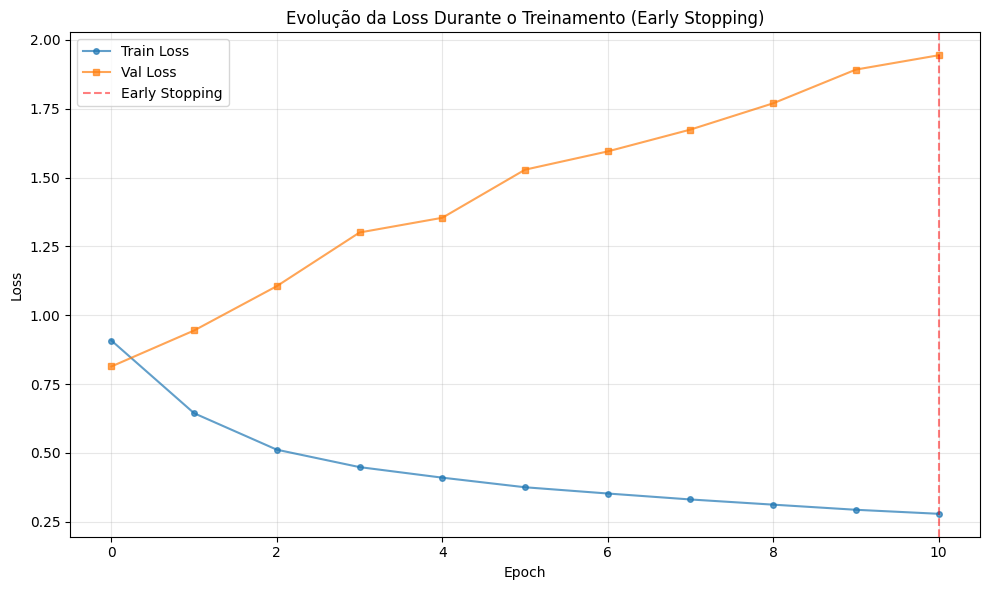

Treinamento completado em 11 epochs.


In [11]:
# Plot: Loss ao longo do treinamento.
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    history["train_loss"],
    label="Train Loss",
    marker="o",
    linestyle="-",
    markersize=4,
    alpha=0.7,
)
ax.plot(
    history["val_loss"],
    label="Val Loss",
    marker="s",
    linestyle="-",
    markersize=4,
    alpha=0.7,
)
ax.axvline(
    x=len(history["train_loss"]) - 1,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="Early Stopping",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Evolução da Loss Durante o Treinamento (Early Stopping)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_epochs_trained = len(history["train_loss"])
print(f"Treinamento completado em {n_epochs_trained} epochs.")

## Visualização: Matriz de Confusão

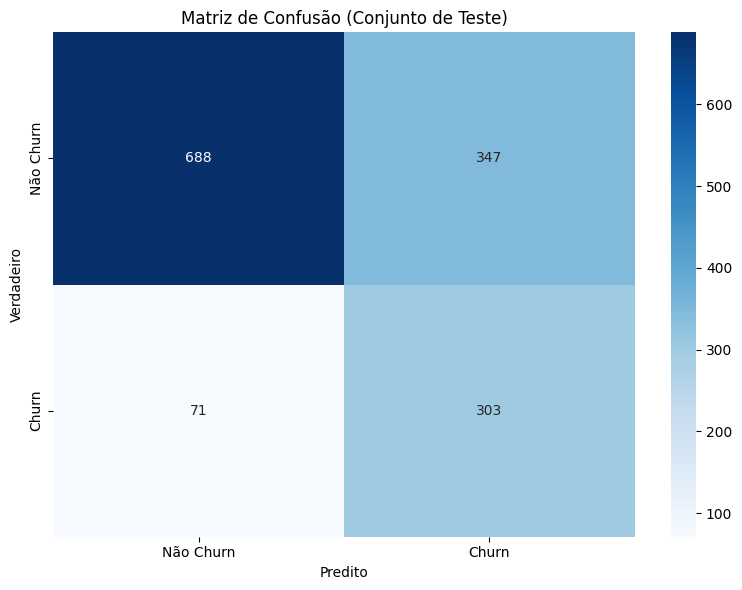


Componentes da Matriz de Confusão:
  TN (Verdadeiro Negativo):  688
  FP (Falso Positivo):       347
  FN (Falso Negativo):       71
  TP (Verdadeiro Positivo):  303


In [12]:
# Calcula matriz de confusão.
cm = confusion_matrix(y_test_true, y_test_pred)

# Plot: Matriz de confusão.
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax,
    cbar=True,
    xticklabels=["Não Churn", "Churn"],
    yticklabels=["Não Churn", "Churn"],
)
ax.set_xlabel("Predito")
ax.set_ylabel("Verdadeiro")
ax.set_title("Matriz de Confusão (Conjunto de Teste)")
plt.tight_layout()
plt.show()

# Extrai componentes da matriz.
tn, fp, fn, tp = cm.ravel()
print(f"\nComponentes da Matriz de Confusão:")
print(f"  TN (Verdadeiro Negativo):  {tn}")
print(f"  FP (Falso Positivo):       {fp}")
print(f"  FN (Falso Negativo):       {fn}")
print(f"  TP (Verdadeiro Positivo):  {tp}")

## Integração com MLflow

In [13]:
# Força o tracking para banco local e evita problemas de caminho.
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")

# Hash do dataset para rastreabilidade.
def file_sha256(path: Path) -> str:
    hash_obj = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_obj.update(chunk)
    return hash_obj.hexdigest()

dataset_version = file_sha256(DATA_PATH)
dataset_name = DATA_PATH.name

# Inicia experimento no MLflow.
mlflow.set_experiment("MLP-Churn-EarlyStoppingBatching")

with mlflow.start_run(run_name="04_mlp_training_early_stopping") as run:
    # Registra parametros de configuracao.
    mlflow.log_param("seed", SEED)
    mlflow.log_param("dataset_name", dataset_name)
    mlflow.log_param("dataset_version_sha256", dataset_version)
    mlflow.log_param("n_amostras_total", int(df.shape[0]))
    mlflow.log_param("n_features", int(n_features))
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("learning_rate", LEARNING_RATE)
    mlflow.log_param("num_epochs_max", NUM_EPOCHS_MAX)
    mlflow.log_param("patience_early_stopping", PATIENCE)
    mlflow.log_param("threshold_prediction", THRESHOLD_PREDICTION)
    mlflow.log_param("threshold_otimo_f1_validacao", THRESHOLD_OTIMO_F1)
    mlflow.log_param("hidden_dim_1", 64)
    mlflow.log_param("hidden_dim_2", 32)
    mlflow.log_param("loss_function", "BCEWithLogitsLoss")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("pos_weight", float(pos_weight_value))

    # Registra métricas finais.
    mlflow.log_metric("test_loss", test_loss)
    mlflow.log_metric("test_accuracy", accuracy)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_f1_score", f1)
    mlflow.log_metric("test_precision_thr_otimo", precision_otimo)
    mlflow.log_metric("test_recall_thr_otimo", recall_otimo)
    mlflow.log_metric("test_f1_thr_otimo", f1_otimo)
    mlflow.log_metric("test_roc_auc", roc_auc)
    mlflow.log_metric("test_pr_auc", pr_auc)
    mlflow.log_metric("best_val_loss", best_val_loss)
    mlflow.log_metric("epochs_trained", n_epochs_trained)
    mlflow.log_metric("confusion_tn", tn)
    mlflow.log_metric("confusion_fp", fp)
    mlflow.log_metric("confusion_fn", fn)
    mlflow.log_metric("confusion_tp", tp)

    # Registra o modelo.
    mlflow.pytorch.log_model(model, "model")

print("\n✓ Experimento registrado no MLflow!")
print(f"ID do Run: {run.info.run_id}")
print(f"Experimento: {run.info.experiment_id}")

Tracking URI: sqlite:///mlflow.db


2026/04/13 21:00:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 21:00:15 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.



✓ Experimento registrado no MLflow!
ID do Run: 86ec79e2703043988e6a05951766bfa4
Experimento: 2


## Resumo Final do Experimento

In [14]:
print("\n" + "="*80)
print("RESUMO — MLP com Loop de Treinamento, Early Stopping e Batching")
print("="*80)
print(f"\nDataset: {DATA_PATH.name}")
print(f"Seed para reprodutibilidade: {SEED}")
print(f"\nSplits:")
print(f"  Treino:      {len(X_train)} amostras (64%)")
print(f"  Validação:   {len(X_val)} amostras (16%)")
print(f"  Teste:       {len(X_test)} amostras (20%)")
print(f"  Features:    {n_features}")
print(f"\nArquitetura MLP:")
print(f"  Input ({n_features}) → 64 (ReLU) → 32 (ReLU) → 1 (Logit)")
print(f"\nHiperparâmetros:")
print(f"  Batch Size:                {BATCH_SIZE}")
print(f"  Learning Rate:             {LEARNING_RATE}")
print(f"  Loss Function:             BCEWithLogitsLoss")
print(f"  pos_weight (classe churn): {pos_weight_value:.4f}")
print(f"  Optimizer:                 Adam")
print(f"  Early Stopping Patience:   {PATIENCE}")
print(f"  Epochs Treinados:          {n_epochs_trained}/{NUM_EPOCHS_MAX}")
print(f"\nThresholds:")
print(f"  Padrão:                    {THRESHOLD_PREDICTION:.2f}")
print(f"  Otimizado por F1 (val):    {THRESHOLD_OTIMO_F1:.2f}")
print(f"\nResultados no Teste (threshold padrão={THRESHOLD_PREDICTION:.2f}):")
print(f"  Loss:       {test_loss:.6f}")
print(f"  Acurácia:   {accuracy:.4f}")
print(f"  Precisão:   {precision:.4f}")
print(f"  Recall:     {recall:.4f}")
print(f"  F1-Score:   {f1:.4f}")
print(f"  ROC-AUC:    {roc_auc:.4f}")
print(f"  PR-AUC:     {pr_auc:.4f}")
print(f"\nResultados no Teste (threshold otimizado={THRESHOLD_OTIMO_F1:.2f}):")
print(f"  Precisão:   {precision_otimo:.4f}")
print(f"  Recall:     {recall_otimo:.4f}")
print(f"  F1-Score:   {f1_otimo:.4f}")
print(f"\nMatriz de Confusão (Teste, threshold padrão):")
print(f"  TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"\nPróximas etapas:")
print(f"  → Comparar com baselines (05_compare_mlp_baselines.ipynb)")
print(f"  → Analisar trade-offs FP vs FN (06_tradeoff_custo_fp_fn.ipynb)")
print(f"  → Consolidar experimentos (07_mlflow_experimentos_mlp_ensembles.ipynb)")
print("="*80)


RESUMO — MLP com Loop de Treinamento, Early Stopping e Batching

Dataset: Telco_customer_churn_ready.csv
Seed para reprodutibilidade: 42

Splits:
  Treino:      4225 amostras (64%)
  Validação:   1409 amostras (16%)
  Teste:       1409 amostras (20%)
  Features:    1162

Arquitetura MLP:
  Input (1162) → 64 (ReLU) → 32 (ReLU) → 1 (Logit)

Hiperparâmetros:
  Batch Size:                64
  Learning Rate:             0.001
  Loss Function:             BCEWithLogitsLoss
  pos_weight (classe churn): 2.7690
  Optimizer:                 Adam
  Early Stopping Patience:   10
  Epochs Treinados:          11/50

Thresholds:
  Padrão:                    0.50
  Otimizado por F1 (val):    0.53

Resultados no Teste (threshold padrão=0.50):
  Loss:       0.817101
  Acurácia:   0.7033
  Precisão:   0.4662
  Recall:     0.8102
  F1-Score:   0.5918
  ROC-AUC:    0.7843
  PR-AUC:     0.5225

Resultados no Teste (threshold otimizado=0.53):
  Precisão:   0.4777
  Recall:     0.7727
  F1-Score:   0.5904

M